# Optimal Transport in linear ICA

#### In this notebook we demonstrate the failure modes of FastICA - 1) Vanishing Curvature Pitfalls and 2) Zero Negentropy Pitfalls.

# Breaking FastICA: Engineered Vanishing Curvature
#### In this notebook, we demonstrate how parametric ICA fails when its core convergence assumptions are violated, and how OT-ICA provides a robust geometric solution.

---

### The Vanishing Curvature Trap
FastICA relies on a fixed contrast function $g(s)$ (typically `logcosh`) to approximate non-Gaussianity. Its stability depends on the **Non-Vanishing Curvature** condition:
$$E[s g(s) - g'(s)] \neq 0$$
When this expectation approaches zero, the Newton-based optimizer loses its "direction," leading to infinite oscillations or random convergence.

### Experiment Overview
We engineer a **Trimodal Gaussian Mixture** (the "Smoothed Discrete Trap") specifically designed to balance positive and negative curvature exactly at zero. This creates a distribution that is clearly non-Gaussian to the human eye, yet mathematically invisible to FastICA's default contrast function.

### Key Objectives:
* **Mathematical Blindness:** Prove that FastICA fails regardless of increased compute (10,000+ iterations) because the failure is in the **objective function**, not the iteration count.
* **Geometric Robustness:** Show that **OT-ICA** succeeds by utilizing the global geometry of the distribution (Wasserstein distance) rather than relying on local parametric derivatives.
* **Scaling Benchmarks:** Measure the **Amari Error** across 5 to 25 dimensions to compare recovery accuracy in both Low and High compute regimes.



### Expected Results:
* **FastICA:** High Amari Error ($> 2.0$) across all dimensions, representing a complete failure to unmix the signals.
* **OT-ICA:** Low Amari Error ($< 0.3$), indicating successful source separation despite the vanishing curvature trap.

In [6]:
import numpy as np
import torch
import pandas as pd
import time
from sklearn.decomposition import FastICA
from scipy.integrate import quad
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
from scipy.optimize import root_scalar
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator

from wasserstein_ica import WassersteinICA

In [7]:
# Define a consistent Thesis Theme
def set_thesis_theme():
    # Academic, colorblind-friendly palette
    # Blue, Orange, Green, Red, Purple, Brown
    thesis_colors = ['#0173B2', '#DE8F05', '#029E73', '#D55E00', '#CC78BC', '#CA9161']
    
    mpl.rcParams.update({
        # Figure and Layout
        'figure.figsize': (8, 5),
        'figure.dpi': 300,            # High resolution for print
        'axes.prop_cycle': mpl.cycler(color=thesis_colors),
        
        # Grid lines (light and unobtrusive)
        'axes.grid': True,
        'grid.alpha': 0.3,
        'grid.linestyle': '--',
        'axes.axisbelow': True,       # Grid goes behind data
        
        # Spines (remove top and right borders for a cleaner look)
        'axes.spines.top': False,
        'axes.spines.right': False,
        
        # Fonts and Text
        'font.size': 11,
        'axes.titlesize': 13,
        'axes.labelsize': 12,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        
        # Legends
        'legend.frameon': False,      # No box around the legend
        'legend.fontsize': 10,
        
        # Lines
        'lines.linewidth': 2.0
    })

# Run this before plotting
set_thesis_theme()

In [8]:
# ==========================================
# 1. The Trimodal Trap Generator
# ==========================================

def find_trimodal_trap_params(sigma=0.15):
    """Finds the optimal b for the Trimodal Gaussian A.5 trap."""
    def h(x):
        return x * np.tanh(x) - 1.0 + np.tanh(x)**2
        
    def target_func(b):
        p = (1.0 - sigma**2) / (2 * b**2)
        
        def pdf(x):
            norm_const = 1.0 / (np.sqrt(2 * np.pi) * sigma)
            term1 = p * np.exp(-0.5 * ((x + b) / sigma)**2)
            term2 = (1 - 2*p) * np.exp(-0.5 * (x / sigma)**2)
            term3 = p * np.exp(-0.5 * ((x - b) / sigma)**2)
            return norm_const * (term1 + term2 + term3)
            
        def integrand(x):
            return h(x) * pdf(x)
            
        # Integrate over a wide enough range to capture the tails
        integral_val, _ = quad(integrand, -10, 10)
        return integral_val

    # The discrete trap found a root near b=1.5, so we search around that value
    sol = root_scalar(target_func, bracket=[1.1, 2.0], method='brentq')
    b_opt = sol.root
    p_opt = (1.0 - sigma**2) / (2 * b_opt**2)
    return b_opt, p_opt, sigma

TRAP_B, TRAP_P, TRAP_SIGMA = find_trimodal_trap_params()
print(f"Calculated Peak Location (b): {TRAP_B:.5f}")
print(f"Calculated Edge Probability (p): {TRAP_P:.5f}")
print(f"Constant Smoothing (sigma): {TRAP_SIGMA:.5f}")

Calculated Peak Location (b): 1.44443
Calculated Edge Probability (p): 0.23426
Constant Smoothing (sigma): 0.15000


In [9]:
def generate_trimodal_trap(n_dim, n_samples, seed=None):
    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)
        
    # 1. Generate the discrete base
    choices = [-TRAP_B, 0.0, TRAP_B]
    probs = [TRAP_P, 1.0 - 2*TRAP_P, TRAP_P]
    
    sources = []
    for _ in range(n_dim):
        # Pick the discrete centers
        centers = np.random.choice(choices, size=n_samples, p=probs)
        # Add the continuous Gaussian noise
        noise = np.random.normal(0, TRAP_SIGMA, size=n_samples)
        sources.append(centers + noise)
        
    S = np.stack(sources)
    
    # Well-conditioned mixing matrix
    cond_num = 1000
    while cond_num > 100:
        A = np.random.randn(n_dim, n_dim)
        cond_num = np.linalg.cond(A)
        
    X = A @ S
    return torch.tensor(X, dtype=torch.float32), A

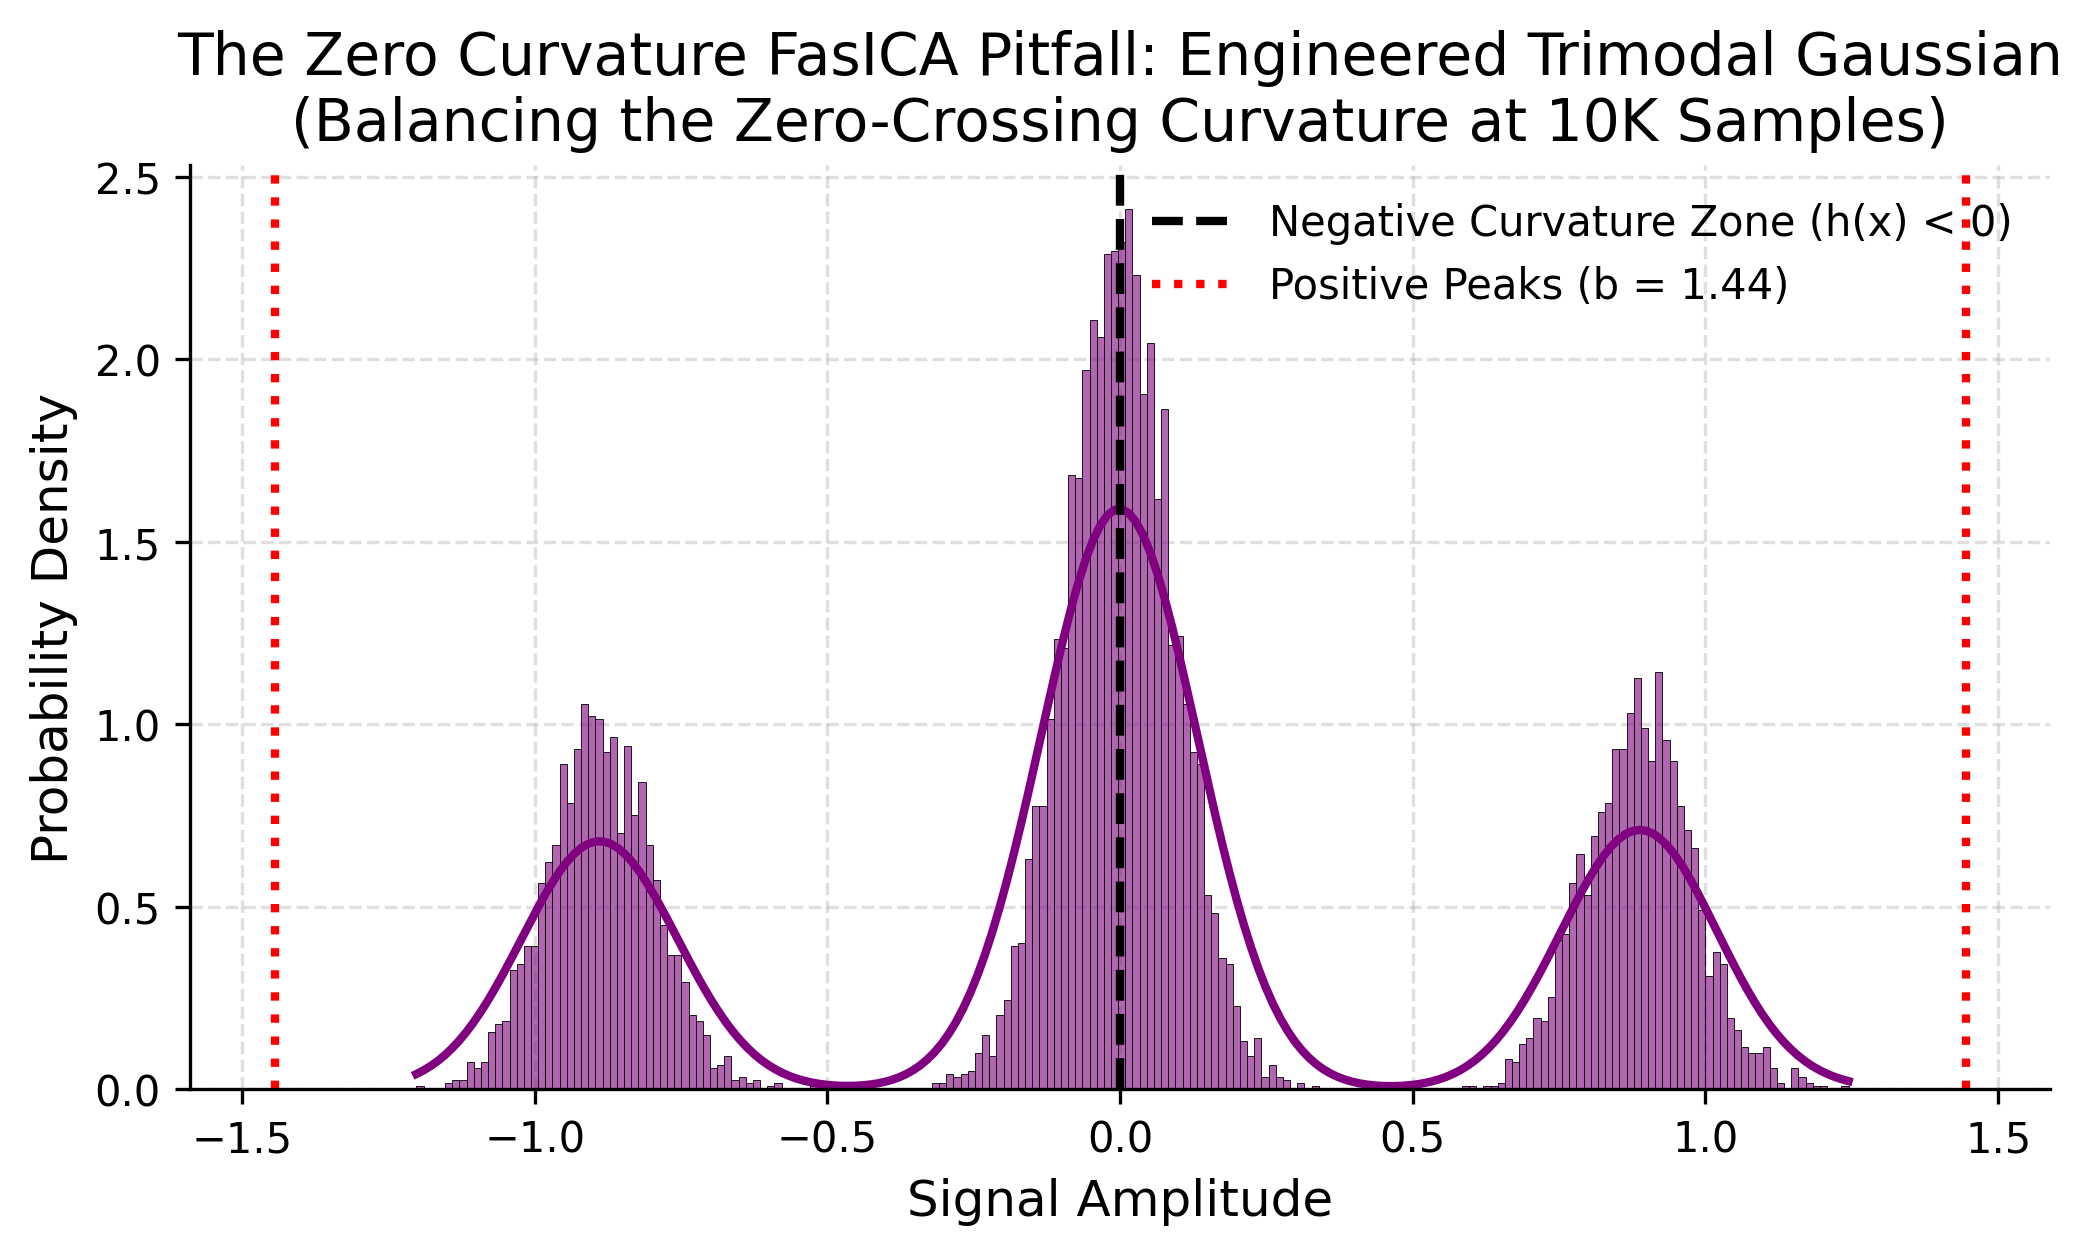

In [10]:
# Generate a 1-dimensional test sample to visualize the shape
test_samples, _ = generate_trimodal_trap(n_dim=1, n_samples=10000, seed=42)
test_np = test_samples.numpy().flatten()

plt.figure(figsize=(8, 4))
sns.histplot(test_np, bins=200, stat="density", color="purple", alpha=0.6, kde=True)

# Overlay the theoretical components to show the trap mechanics
plt.axvline(0, color='black', linestyle='--', label='Negative Curvature Zone (h(x) < 0)')
plt.axvline(-TRAP_B, color='red', linestyle=':', label=f'Positive Peaks (b = {TRAP_B:.2f})')
plt.axvline(TRAP_B, color='red', linestyle=':')

plt.title("The Zero Curvature FasICA Pitfall: Engineered Trimodal Gaussian\n(Balancing the Zero-Crossing Curvature at 10K Samples)", fontsize=14)
plt.xlabel("Signal Amplitude")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

In [11]:
# ==========================================
# 2. Parallel Worker Function (GPU Enabled)
# ==========================================
def run_trimodal_trap_trial(dim, trial, compute_level):
    torch.set_num_threads(1) 
    trial_results = []
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    n_samples = 10000  # Fixed at 10K
    X_torch, A_true = generate_trimodal_trap(n_dim=dim, n_samples=n_samples, seed=trial)
    X_torch = X_torch.to(device)
    X_np = X_torch.cpu().numpy()
    
    # Configure Compute Parameters
    if compute_level == 'Low Compute':
        fast_max_iter = 1000
        w2_restarts = min(dim * 4, 150)
        w2_def_iter = 150
        w2_sym_iter = 300
    else: # High Compute
        fast_max_iter = 10000 # Prove it oscillates infinitely
        w2_restarts = min(dim * 15, 600) # Massive parallel search
        w2_def_iter = 300
        w2_sym_iter = 800
    
    # --- FastICA ---
    try:
        fast_ica = FastICA(n_components=dim, max_iter=fast_max_iter, tol=1e-4, random_state=trial)
        fast_ica.fit(X_np.T)
        W_fast_total = fast_ica.components_
        score_fast = amari_error(W_fast_total, A_true) 
    except Exception as e:
        print(f"FastICA Error (dim {dim}): {e}")
        score_fast = np.nan 
            
    trial_results.append({
        'Dimension': dim, 
        'Method': 'FastICA', 
        'Compute Level': compute_level, 
        'Amari Error': score_fast
    })
    
    # --- W2-ICA (Stiefel) ---
    try:
        ica = WassersteinICA(X_torch)
        ica.whiten()
        W_white_np = ica.W_white.cpu().numpy()
        
        extracted_ws = []
        
        # 1. Deflation Phase 
        for _ in range(dim):
            prev = torch.stack(extracted_ws) if extracted_ws else None
            w, _ = ica.optimize_wasserstein2(
                prev_components=prev, 
                max_iter=w2_def_iter, 
                n_restarts=w2_restarts,
                dither_sigma=0.01  
            )
            extracted_ws.append(w)
            
        W_deflation_init = torch.stack(extracted_ws)
        
        # 2. Symmetric Stiefel Phase 
        W_stiefel_unmixed = ica.optimize_symmetric(
            n_components=dim, 
            max_iter=w2_sym_iter,        
            lr=0.25,             
            init_w=W_deflation_init, 
            optimizer='stiefel',
            use_sinkhorn=False,
            dither_sigma=0.01,   
            batch_size=1024      
        )
        W_wass_total = W_stiefel_unmixed.cpu().numpy() @ W_white_np
        score_wass = amari_error(W_wass_total, A_true)
        
    except Exception as e:
        print(f"W2-ICA Error (dim {dim}): {e}")
        score_wass = np.nan
        
    trial_results.append({
        'Dimension': dim, 
        'Method': 'OT-ICA', 
        'Compute Level': compute_level, 
        'Amari Error': score_wass
    })
    
    return trial_results

In [ ]:
# ==========================================
# 3. Main Execution
# ==========================================
DIMENSIONS = list(range(5, 26, 5))
COMPUTE_LEVELS = ['Low Compute', 'High Compute']
N_TRIALS = 5

print(f"--- OT vs FastICA Trimodal Gaussian ---")

tasks = [(dim, trial, comp) 
         for dim in DIMENSIONS 
         for trial in range(N_TRIALS) 
         for comp in COMPUTE_LEVELS]

results_nested = []

with Parallel(n_jobs=12, return_as="generator") as parallel:
    jobs = (delayed(run_trimodal_trap_trial)(dim, trial, comp) for dim, trial, comp in tasks)
    for res in tqdm(parallel(jobs), total=len(tasks), desc="Running Trimodal Trials"):
        results_nested.append(res)

results = [item for sublist in results_nested for item in sublist]
df_trimodal = pd.DataFrame(results)

In [ ]:
# ==========================================
# 4. Plotting
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Updated Palette: FastICA is Blue, OT-ICA is Orange
palette = {'FastICA': '#0173B2', 'OT-ICA': '#D55E00'}

# --- Subplot 1: Low Compute ---
df_low = df_trimodal[df_trimodal['Compute Level'] == 'Low Compute']
sns.lineplot(
    data=df_low, 
    x='Dimension', 
    y='Amari Error', 
    hue='Method', 
    palette=palette,
    marker='o', 
    linewidth=2.5,
    markersize=8,
    ax=axes[0]
)
axes[0].set_title("Low Compute Regime", fontsize=14)
axes[0].set_ylabel("Amari Error (Lower is Better)", fontsize=13)
axes[0].set_xlabel("Number of Dimensions", fontsize=13)
axes[0].set_xticks(DIMENSIONS)
axes[0].axhline(0.3, color='gray', linestyle=':', alpha=0.8, linewidth=2)
axes[0].text(5.5, 0.35, 'Good Separation', color='gray', fontsize=11)

# Clean up legend for left plot
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles=handles, labels=labels, title='Method', loc='upper left', fontsize=11)

# --- Subplot 2: High Compute ---
df_high = df_trimodal[df_trimodal['Compute Level'] == 'High Compute']
sns.lineplot(
    data=df_high, 
    x='Dimension', 
    y='Amari Error', 
    hue='Method', 
    palette=palette,
    marker='o', 
    linewidth=2.5,
    markersize=8,
    ax=axes[1]
)
axes[1].set_title("High Compute Regime", fontsize=14)
axes[1].set_ylabel("") # Y-axis label is shared and handled by the left plot
axes[1].set_xlabel("Number of Dimensions", fontsize=13)
axes[1].set_xticks(DIMENSIONS)
axes[1].axhline(0.3, color='gray', linestyle=':', alpha=0.8, linewidth=2)

# Remove redundant legend on the right plot
if axes[1].get_legend() is not None:
    axes[1].get_legend().remove()

# --- Global Formatting ---
plt.ylim(0, 4)
axes[0].yaxis.set_major_locator(MultipleLocator(0.5))

fig.suptitle("Amari Error vs. Dimension: The Vanishing Curvature Pitfall\n(Algorithmic Failure vs. Optimization Complexity)", fontsize=15, y=1.05)

plt.tight_layout()
#plt.savefig('vanishing_curvature_amari_compute.png', dpi=300, bbox_inches='tight')
plt.show()

# Display summary table
summary_table = df_trimodal.groupby(['Dimension', 'Method', 'Compute Level'])['Amari Error'].mean().unstack(level=[1,2]).round(4)
display(summary_table)

## Identifying the Zero-Negentropy Trap: FastICA vs. OT-ICA

---

### The Zero-Negentropy Pitfall
Standard ICA algorithms like **FastICA** rely on non-Gaussianity measures (such as Negentropy or Kurtosis) to separate signals. These are typically approximated using a contrast function, such as $G(x) = \log(\cosh(x))$.

However, it is possible to construct a specific non-Gaussian distribution—a **Phantom Gaussian**—where the expected value of the contrast function exactly matches that of a standard Gaussian:
$$E[G(X_{phantom})] \approx E[G(X_{gaussian})]$$

In this scenario, FastICA becomes "blind" to the signal because the gradient of the objective function disappears, causing the algorithm to fail even with infinite compute.

### Experiment Overview
This experiment benchmarks **FastICA** against **OT-ICA (Wasserstein-2)** across increasing dimensionality (5 to 25 dimensions) to test for algorithmic robustness.

* **The Trap:** We generate sources using a custom Gaussian mixture (The "Phantom Trap") designed to yield zero negentropy under standard contrast functions.
* **Performance Metric:** We use the **Amari Error** to measure the accuracy of the recovered mixing matrix (lower is better).
* **Compute Regimes:** We test both methods under **Low Compute** and **High Compute** settings to determine if failures are due to a lack of iterations or a fundamental flaw in the objective function.

### Key Insights to Observe:
* **Algorithmic Blindness:** FastICA is expected to maintain high Amari Error regardless of dimensionality or compute power, as its objective function cannot "see" the sources.
* **Wasserstein Robustness:** OT-ICA uses the full distribution geometry via the Wasserstein-2 distance, allowing it to bypass the zero-negentropy trap and successfully unmix the components.
* **Dimensionality Scaling:** We observe how the optimization complexity of OT-ICA scales as we move into higher-dimensional latent spaces.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
from scipy.optimize import root_scalar
from scipy.integrate import quad
from scipy.stats import norm
from matplotlib.ticker import MultipleLocator
from sklearn.decomposition import FastICA
import warnings

In [13]:
# ==========================================
# 1. The Zero-Negentropy Trap Generator
# ==========================================
def g_func(x):
    return np.log(np.cosh(x))

def gaussian_integrand(x):
    return g_func(x) * norm.pdf(x)

GAUSSIAN_BASELINE, _ = quad(gaussian_integrand, -10, 10)

def find_zero_negentropy_params(sigma=0.15):
    """Finds the optimal b for the Zero-Negentropy trap."""
    def target_func(b):
        p = (1.0 - sigma**2) / (2 * b**2)
        
        def pdf(x):
            norm_const = 1.0 / (np.sqrt(2 * np.pi) * sigma)
            term1 = p * np.exp(-0.5 * ((x + b) / sigma)**2)
            term2 = (1 - 2*p) * np.exp(-0.5 * (x / sigma)**2)
            term3 = p * np.exp(-0.5 * ((x - b) / sigma)**2)
            return norm_const * (term1 + term2 + term3)
            
        def integrand(x):
            return g_func(x) * pdf(x)
            
        integral_val, _ = quad(integrand, -10, 10)
        return integral_val - GAUSSIAN_BASELINE

    sol = root_scalar(target_func, bracket=[1.1, 1.8], method='brentq')
    b_opt = sol.root
    p_opt = (1.0 - sigma**2) / (2 * b_opt**2)
    return b_opt, p_opt, sigma

TRAP_B, TRAP_P, TRAP_SIGMA = find_zero_negentropy_params()
print(f"Calculated Phantom Boundary (b): {TRAP_B:.5f}")
print(f"Calculated Phantom Edge Probability (p): {TRAP_P:.5f}")

def generate_phantom_trap(n_dim, n_samples, seed=None):
    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)
        
    choices = [-TRAP_B, 0.0, TRAP_B]
    probs = [TRAP_P, 1.0 - 2*TRAP_P, TRAP_P]
    
    sources = []
    for _ in range(n_dim):
        centers = np.random.choice(choices, size=n_samples, p=probs)
        noise = np.random.normal(0, TRAP_SIGMA, size=n_samples)
        sources.append(centers + noise)
        
    S = np.stack(sources)
    
    cond_num = 1000
    while cond_num > 100:
        A = np.random.randn(n_dim, n_dim)
        cond_num = np.linalg.cond(A)
        
    X = A @ S
    return torch.tensor(X, dtype=torch.float32), A

Calculated Phantom Boundary (b): 1.54340
Calculated Phantom Edge Probability (p): 0.20518


In [14]:
# ==========================================
# 2. Parallel Worker Function (GPU Enabled)
# ==========================================
def run_phantom_trial(dim, trial, compute_level):
    torch.set_num_threads(1) 
    trial_results = []
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    n_samples = 10000  # Fixed at 10K
    X_torch, A_true = generate_phantom_trap(n_dim=dim, n_samples=n_samples, seed=trial)
    X_torch = X_torch.to(device)
    X_np = X_torch.cpu().numpy()
    
    # Configure Compute Parameters
    if compute_level == 'Low Compute':
        fast_max_iter = 1000
        w2_restarts = min(dim * 4, 150)
        w2_def_iter = 150
        w2_sym_iter = 300
    else: # High Compute
        fast_max_iter = 10000 
        w2_restarts = min(dim * 15, 600) 
        w2_def_iter = 300
        w2_sym_iter = 800
    
    # --- FastICA ---
    try:
        # FastICA typically fails silently here due to zero gradient, not max iterations
        fast_ica = FastICA(n_components=dim, max_iter=fast_max_iter, tol=1e-4, random_state=trial)
        fast_ica.fit(X_np.T)
        W_fast_total = fast_ica.components_
        score_fast = amari_error(W_fast_total, A_true) 
    except Exception as e:
        print(f"FastICA Error (dim {dim}): {e}")
        score_fast = np.nan 
            
    trial_results.append({
        'Dimension': dim, 
        'Method': 'FastICA', 
        'Compute Level': compute_level, 
        'Amari Error': score_fast
    })
    
    # --- W2-ICA (Stiefel) ---
    try:
        ica = WassersteinICA(X_torch)
        ica.whiten()
        W_white_np = ica.W_white.cpu().numpy()
        
        extracted_ws = []
        
        # 1. Deflation Phase 
        for _ in range(dim):
            prev = torch.stack(extracted_ws) if extracted_ws else None
            w, _ = ica.optimize_wasserstein2(
                prev_components=prev, 
                max_iter=w2_def_iter, 
                n_restarts=w2_restarts,
                dither_sigma=0.01  
            )
            extracted_ws.append(w)
            
        W_deflation_init = torch.stack(extracted_ws)
        
        # 2. Symmetric Stiefel Phase 
        W_stiefel_unmixed = ica.optimize_symmetric(
            n_components=dim, 
            max_iter=w2_sym_iter,        
            lr=0.25,             
            init_w=W_deflation_init, 
            optimizer='stiefel',
            use_sinkhorn=False,
            dither_sigma=0.01,   
            batch_size=1024      
        )
        W_wass_total = W_stiefel_unmixed.cpu().numpy() @ W_white_np
        score_wass = amari_error(W_wass_total, A_true)
        
    except Exception as e:
        print(f"W2-ICA Error (dim {dim}): {e}")
        score_wass = np.nan
        
    trial_results.append({
        'Dimension': dim, 
        'Method': 'OT-ICA', 
        'Compute Level': compute_level, 
        'Amari Error': score_wass
    })
    
    return trial_results

In [ ]:
# ==========================================
# 3. Main Execution
# ==========================================
DIMENSIONS = list(range(5, 26, 5))
COMPUTE_LEVELS = ['Low Compute', 'High Compute']
N_TRIALS = 5

print(f"--- FastICA Phantom Gaussian (Zero-Negentropy Trap) Showdown ---")

tasks = [(dim, trial, comp) 
         for dim in DIMENSIONS 
         for trial in range(N_TRIALS) 
         for comp in COMPUTE_LEVELS]

results_nested = []

with Parallel(n_jobs=12, return_as="generator") as parallel:
    jobs = (delayed(run_phantom_trial)(dim, trial, comp) for dim, trial, comp in tasks)
    for res in tqdm(parallel(jobs), total=len(tasks), desc="Running Phantom Trials"):
        results_nested.append(res)

results = [item for sublist in results_nested for item in sublist]
df_phantom = pd.DataFrame(results)

In [ ]:
# ==========================================
# 4. Plotting
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Palette: FastICA is Blue, OT-ICA is Orange
palette = {'FastICA': '#0173B2', 'OT-ICA': '#D55E00'}

# --- Subplot 1: Low Compute ---
df_low = df_phantom[df_phantom['Compute Level'] == 'Low Compute']
sns.lineplot(
    data=df_low, 
    x='Dimension', 
    y='Amari Error', 
    hue='Method', 
    palette=palette,
    marker='o', 
    linewidth=2.5,
    markersize=8,
    ax=axes[0]
)
axes[0].set_title("Low Compute Regime", fontsize=14)
axes[0].set_ylabel("Amari Error (Lower is Better)", fontsize=13)
axes[0].set_xlabel("Number of Dimensions", fontsize=13)
axes[0].set_xticks(DIMENSIONS)
axes[0].axhline(0.3, color='gray', linestyle=':', alpha=0.8, linewidth=2)
axes[0].text(5.5, 0.35, 'Good Separation', color='gray', fontsize=11)

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles=handles, labels=labels, title='Method', loc='upper left', fontsize=11)

# --- Subplot 2: High Compute ---
df_high = df_phantom[df_phantom['Compute Level'] == 'High Compute']
sns.lineplot(
    data=df_high, 
    x='Dimension', 
    y='Amari Error', 
    hue='Method', 
    palette=palette,
    marker='o', 
    linewidth=2.5,
    markersize=8,
    ax=axes[1]
)
axes[1].set_title("High Compute Regime", fontsize=14)
axes[1].set_ylabel("") 
axes[1].set_xlabel("Number of Dimensions", fontsize=13)
axes[1].set_xticks(DIMENSIONS)
axes[1].axhline(0.3, color='gray', linestyle=':', alpha=0.8, linewidth=2)

if axes[1].get_legend() is not None:
    axes[1].get_legend().remove()

# --- Global Formatting ---
plt.ylim(0, 4)
axes[0].yaxis.set_major_locator(MultipleLocator(0.5))

fig.suptitle("Amari Error vs. Dimension: The Zero-Negentropy Pitfall\n(Algorithmic Blindness vs. Optimization Complexity)", fontsize=15, y=1.05)

plt.tight_layout()
#plt.savefig('zero_negentropy_amari_compute.png', dpi=300, bbox_inches='tight')
plt.show()

summary_table = df_phantom.groupby(['Dimension', 'Method', 'Compute Level'])['Amari Error'].mean().unstack(level=[1,2]).round(4)
display(summary_table)